---
title: "SARIMAX (Covid, Unemployment)"
format: html
number-sections: true
jupyter: python3
python: ~/venv/bin/python3
---

Load in Python libraries.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

Load in Data. Impute missing values.

In [3]:
# crime 
crime = pd.read_csv("rms_crime_incidents.csv")

# unemployment
unemployment = pd.read_csv('unemployment_wayne_county.csv')

# missing value
missing = unemployment.index[unemployment['Value'] == '-'][0]
before_missing = unemployment['Value'][missing - 1]
after_missing =  unemployment['Value'][missing + 1]
avg = (pd.to_numeric(before_missing) + pd.to_numeric(after_missing)) / 2
unemployment['Value'] = unemployment['Value'].replace('-', avg)
unemployment['Value'] = pd.to_numeric(unemployment['Value'])

Crime data cleaning.

In [4]:
crime['incident_occurred_at'] = pd.to_datetime(crime['incident_occurred_at'])

# monthly period
crime['Month'] = crime['incident_occurred_at'].dt.to_period('M')

# aggregate counts over each month and year starting from 2017
crime_monthly = crime.groupby('Month').size().reset_index(name='Incidents')
crime_monthly['Month'] = crime_monthly['Month'].dt.to_timestamp()
crime_monthly = crime_monthly[crime_monthly['Month'].dt.year >= 2017]

Unemployment data cleaning.

In [5]:
unemployment['Label'] =  pd.to_datetime(unemployment['Label'])
unemployment['Label'] = unemployment['Label'].dt.to_period('M')
unemployment['Label'] = unemployment['Label'].dt.to_timestamp()
unemployment = unemployment[unemployment['Label'].dt.year >= 2017]

Covid labels.

In [6]:
edges = [pd.Timestamp("2017-01-01"),pd.Timestamp("2020-03-01",), pd.Timestamp("2022-07-01"), pd.Timestamp("2026-01-01")] #since unemployment limited to 2025

labels = ["pre", "during", "post"]

crime_monthly["covid"] = pd.cut(crime_monthly["Month"], bins=edges, labels=labels, right=False)
crime_monthly = crime_monthly.dropna()
unemployment["covid"] = pd.cut(unemployment["Label"], bins=edges, labels=labels, right=False)

# Unemployment and covid

Exogenous dataframe with unemployment and covid

In [7]:
covid_dummy = pd.get_dummies(crime_monthly["covid"], drop_first=True).astype(float)

covid_dummy_during = covid_dummy['during'].reset_index(drop=True)
covid_dummy_post   = covid_dummy['post'].reset_index(drop=True)

no_of_incidents = crime_monthly['Incidents'].reset_index(drop=True)
unemployment_values = unemployment['Value'].reset_index(drop=True)

exog_vars = pd.concat([covid_dummy[['during','post']].reset_index(drop=True),
unemployment_values.reset_index(drop=True)],axis=1)

exog_vars.columns = ['covid_during', 'covid_post', 'unemployment']


# Checks to see if indexing was correct
# covid_dummy_during.index
# covid_dummy_post.index
# unemployment_values.index

print(exog_vars.isna().sum())
print(no_of_incidents.isna().sum())

len(no_of_incidents)
len(exog_vars)

print(exog_vars['unemployment'].isna().sum())
print(unemployment_values.isna().sum())
print(covid_dummy_during.index.equals(unemployment_values.index))

covid_during    0
covid_post      0
unemployment    0
dtype: int64
0
0
0
True


## Modeling with linear Trend

In [8]:
def sarima_aic_table(data, p_max, q_max, P_max, Q_max, m):
    results = []
    # Iterate through all combinations
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            for P in range(P_max + 1):
                for Q in range(Q_max + 1):
                    try:
                        model = SARIMAX(data, order=(p,0,q), trend='t',
                        seasonal_order=(P, 0, Q, m), exog = exog_vars)
                        results_fit = model.fit(disp=False)
                        results.append([p, q, P, Q, results_fit.aic])
                    except:
                        results.append([p, q, P, Q, np.nan])
                        
    # Create DataFrame
    df = pd.DataFrame(results, columns=['AR(p)', 'MA(q)', 'SAR(P)', 'SMA(Q)', 'AIC'])
    df.sort_values(by='AIC')
    # Sort by AIC ascending
    return df.sort_values(by='AIC')

sarima_results = sarima_aic_table(no_of_incidents, 2, 2, 2, 2, 12)
sarima_results.head(10)

,AR(p),MA(q),SAR(P),SMA(Q),AIC
33,1,0,2,0,1694.147413
27,1,0,0,0,1703.382742
30,1,0,1,0,1705.611451
28,1,0,0,1,1718.751269
34,1,0,2,1,1725.760367
54,2,0,0,0,1728.820491
36,1,1,0,0,1744.227828
41,1,1,1,2,1753.963235
66,2,1,1,0,1756.560693
12,0,1,1,0,1810.857644


AR1 SAR2

In [9]:
ar1sar2 = SARIMAX(no_of_incidents, order=(1,0,0), trend='t', exog = exog_vars,seasonal_order=(2, 0, 0, 12)).fit()

print(ar1sar2.summary().tables[1]) # not enough evidence for the drift.

ar_roots = ar1sar2.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) # Possibly too close to boundary. 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
drift            0.0992      1.091      0.091      0.928      -2.038       2.237
covid_during  -146.8916    634.913     -0.231      0.817   -1391.299    1097.516
covid_post    3891.8292    796.584      4.886      0.000    2330.553    5453.105
unemployment   -42.7165     45.246     -0.944      0.345    -131.397      45.964
ar.L1            0.9592      0.024     39.500      0.000       0.912       1.007
ar.S.L12         0.3656      0.067      5.484      0.000       0.235       0.496
ar.S.L24         0.3305      0.060      5.540      0.000       0.214       0.447
sigma2        2.925e+05   6.88e+04      4.254      0.000    1.58e+05    4.27e+05
Magnitude of AR roots: [1.02025844 1.07486918 1.07486918 1.02025844 1.02025844 1.07486918
 1.07486918 1.02025844 1.02025844 1.07486918 1.07486918 1.02025844
 1.02025844 1.07486918 1.07486918

AR1: Unit roots

AR1 SAR1

In [10]:
ar1sar1 = SARIMAX(no_of_incidents, order=(1,0,0), trend='t', exog = exog_vars,seasonal_order=(1, 0, 0, 12)).fit()

print(ar1sar1.summary().tables[1]) # not enough evidence for the drift or employment

ar_roots = ar1sar1.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) # Close to boundary
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
drift           -0.4353      1.712     -0.254      0.799      -3.791       2.920
covid_during   -94.9859    774.932     -0.123      0.902   -1613.825    1423.853
covid_post    3829.5851    964.730      3.970      0.000    1938.748    5720.422
unemployment    -1.9644     20.198     -0.097      0.923     -41.552      37.623
ar.L1            0.9888      0.031     32.053      0.000       0.928       1.049
ar.S.L12         0.3598      0.073      4.898      0.000       0.216       0.504
sigma2        3.654e+05   7.68e+04      4.755      0.000    2.15e+05    5.16e+05
Magnitude of AR roots: [1.08892761 1.08892761 1.08892761 1.08892761 1.08892761 1.08892761
 1.08892761 1.08892761 1.08892761 1.08892761 1.08892761 1.01136208
 1.08892761]
Magnitude of AR roots > 1.1: [False False False False False False False False False False False False

AR1 SMA1: Unit roots

AR1 SAR2 MA1: Unit roots


## Modeling with constant mean

In [11]:
def sarima_aic_table(data, p_max, q_max, P_max, Q_max, m):
    results = []
    # Iterate through all combinations
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            for P in range(P_max + 1):
                for Q in range(Q_max + 1):
                    try:
                        model = SARIMAX(data, order=(p,0,q), trend='c',
                        seasonal_order=(P, 0, Q, m), exog = exog_vars)
                        results_fit = model.fit(disp=False)
                        results.append([p, q, P, Q, results_fit.aic])
                    except:
                        results.append([p, q, P, Q, np.nan])
                        
    # Create DataFrame
    df = pd.DataFrame(results, columns=['AR(p)', 'MA(q)', 'SAR(P)', 'SMA(Q)', 'AIC'])
    df.sort_values(by='AIC')
    # Sort by AIC ascending
    return df.sort_values(by='AIC')

sarima_results = sarima_aic_table(no_of_incidents, 2, 2, 2, 2, 12)
print(sarima_results.head())

    AR(p)  MA(q)  SAR(P)  SMA(Q)          AIC
33      1      0       2       0  1689.447386
60      2      0       2       0  1690.961132
30      1      0       1       0  1697.878848
29      1      0       0       2  1701.292955
39      1      1       1       0  1710.732689


AR1 SAR2

In [12]:
ar1sar2 = SARIMAX(no_of_incidents, order=(1,0,0), trend='c', exog = exog_vars,seasonal_order=(2, 0, 0, 12)).fit()

print(ar1sar2.summary().tables[1]) # not enough evidence for covid_during or unemployment

ar_roots = ar1sar2.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) # Possibly too close to boundary. 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      230.1732    109.692      2.098      0.036      15.180     445.166
covid_during  -149.4689    757.151     -0.197      0.844   -1633.457    1334.519
covid_post    3888.6893    859.736      4.523      0.000    2203.637    5573.742
unemployment   -42.9839     42.586     -1.009      0.313    -126.451      40.483
ar.L1            0.8930      0.063     14.069      0.000       0.769       1.017
ar.S.L12         0.3351      0.081      4.141      0.000       0.177       0.494
ar.S.L24         0.2956      0.067      4.443      0.000       0.165       0.426
sigma2        2.935e+05   7.25e+04      4.051      0.000    1.52e+05    4.36e+05
Magnitude of AR roots: [1.02582033 1.07905267 1.07905267 1.02582033 1.02582033 1.07905267
 1.07905267 1.02582033 1.02582033 1.07905267 1.07905267 1.02582033
 1.02582033 1.07905267 1.07905267

AR2 SAR2

In [13]:
ar2sar2 = SARIMAX(no_of_incidents, order=(2,0,0), trend='c', exog = exog_vars,seasonal_order=(2, 0, 0, 12)).fit()

print(ar2sar2.summary().tables[1]) # not enough for mean, covid during, unemployment, or ar.L2

ar_roots = ar2sar2.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) # Possibly too close to boundary. 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      252.4033    118.671      2.127      0.033      19.812     484.994
covid_during  -145.1614    773.518     -0.188      0.851   -1661.229    1370.906
covid_post    3886.0100    874.155      4.445      0.000    2172.697    5599.323
unemployment   -44.5087     39.360     -1.131      0.258    -121.653      32.636
ar.L1            0.8076      0.121      6.649      0.000       0.570       1.046
ar.L2            0.0813      0.129      0.628      0.530      -0.172       0.335
ar.S.L12         0.3359      0.083      4.063      0.000       0.174       0.498
ar.S.L24         0.2825      0.069      4.069      0.000       0.146       0.419
sigma2        2.931e+05    7.4e+04      3.960      0.000    1.48e+05    4.38e+05
Magnitude of AR roots: [ 1.02712321  1.08175502  1.08175502  1.02712321  1.02712321  1.08175502
  1.08175502 

AR1 SAR1

In [14]:
ar1sar1 = SARIMAX(no_of_incidents, order=(1,0,0), trend='c', exog = exog_vars,seasonal_order=(1, 0, 0, 12)).fit()

print(ar1sar1.summary().tables[1]) # not enough for mean, covid during, or unemployment

ar_roots = ar1sar1.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) # Farthest from boundary so far...
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      223.6428    163.148      1.371      0.170     -96.122     543.407
covid_during  -149.3502    599.624     -0.249      0.803   -1324.592    1025.892
covid_post    3889.1030    773.105      5.030      0.000    2373.845    5404.361
unemployment   -39.6744     47.247     -0.840      0.401    -132.276      52.927
ar.L1            0.9151      0.067     13.570      0.000       0.783       1.047
ar.S.L12         0.5048      0.070      7.234      0.000       0.368       0.642
sigma2        3.266e+05   7.27e+04      4.495      0.000    1.84e+05    4.69e+05
Magnitude of AR roots: [1.05861765 1.05861765 1.05861765 1.05861765 1.05861765 1.05861765
 1.05861765 1.05861765 1.05861765 1.05861765 1.05861765 1.05861765
 1.09271763]
Magnitude of AR roots > 1.1: [False False False False False False False False False False False False

AR1 SMA2

In [15]:
ar1sma2= SARIMAX(no_of_incidents, order=(1,0,0), trend='c', exog = exog_vars,seasonal_order=(0, 0, 2, 12)).fit()

print(ar1sma2.summary().tables[1]) # not enough for mean, covid during, unemployment

ar_roots = ar1sma2.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) # Same as above, around 1.05
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

ma_roots = ar1sma2.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) # Same as above, around 1.05
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      229.4284    308.180      0.744      0.457    -374.592     833.449
covid_during  -149.8296    863.431     -0.174      0.862   -1842.124    1542.465
covid_post    3890.7652   1034.348      3.762      0.000    1863.480    5918.050
unemployment   -38.8017     52.677     -0.737      0.461    -142.046      64.443
ar.L1            0.9515      0.059     16.076      0.000       0.835       1.067
ma.S.L12         0.3400      0.080      4.255      0.000       0.183       0.497
ma.S.L24         0.2979      0.106      2.821      0.005       0.091       0.505
sigma2        3.303e+05   6.82e+04      4.843      0.000    1.97e+05    4.64e+05
Magnitude of AR roots: [1.05102413]
Magnitude of AR roots > 1.1: [False]
Magnitude of MA roots: [1.0517493 1.0517493 1.0517493 1.0517493 1.0517493 1.0517493 1.0517493
 1.0517493 1.0517493 1.

AR1 SMA2

In [16]:
ar1ma1sar1= SARIMAX(no_of_incidents, order=(1,0,1), trend='c', exog = exog_vars,seasonal_order=(1, 0, 0, 12)).fit()

print(ar1ma1sar1.summary().tables[1]) # not enough for mean, covid_during, ma.L1 

ar_roots = ar1ma1sar1.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) # 1.08 not too bad
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

ma_roots = ar1ma1sar1.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) 
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1) # These look good too

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      243.9848    204.186      1.195      0.232    -156.212     644.182
covid_during  -141.8331    665.889     -0.213      0.831   -1446.951    1163.285
covid_post    3885.0846    784.138      4.955      0.000    2348.202    5421.968
unemployment   -69.0465     39.201     -1.761      0.078    -145.879       7.786
ar.L1            0.9320      0.059     15.750      0.000       0.816       1.048
ma.L1            0.1511      0.124      1.221      0.222      -0.091       0.394
ar.S.L12         0.3919      0.063      6.204      0.000       0.268       0.516
sigma2        3.024e+05   5.45e+04      5.545      0.000    1.96e+05    4.09e+05
Magnitude of AR roots: [1.08119997 1.08119997 1.08119997 1.08119997 1.08119997 1.08119997
 1.08119997 1.08119997 1.08119997 1.08119997 1.08119997 1.07294457
 1.08119997]
Magnitude of AR root

# Covid only

## Modeling with linear trend

In [17]:
exog_covid = exog_vars[['covid_during', 'covid_post']]

def sarima_aic_table(data, p_max, q_max, P_max, Q_max, m):
    results = []
    # Iterate through all combinations
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            for P in range(P_max + 1):
                for Q in range(Q_max + 1):
                    try:
                        model = SARIMAX(data, order=(p,0,q), trend='t',
                        seasonal_order=(P, 0, Q, m), exog = exog_covid)
                        results_fit = model.fit(disp=False)
                        results.append([p, q, P, Q, results_fit.aic])
                    except:
                        results.append([p, q, P, Q, np.nan])
                        
    # Create DataFrame
    df = pd.DataFrame(results, columns=['AR(p)', 'MA(q)', 'SAR(P)', 'SMA(Q)', 'AIC'])
    df.sort_values(by='AIC')
    # Sort by AIC ascending
    return df.sort_values(by='AIC')

sarima_results = sarima_aic_table(no_of_incidents, 2, 2, 2, 2, 12)
sarima_results.head(10)

,AR(p),MA(q),SAR(P),SMA(Q),AIC
27,1,0,0,0,1698.119600
39,1,1,1,0,1743.755412
56,2,0,0,2,1744.284687
66,2,1,1,0,1744.480986
37,1,1,0,1,1744.859708
54,2,0,0,0,1747.015551
28,1,0,0,1,1748.437419
36,1,1,0,0,1749.361113
60,2,0,2,0,1753.275318
33,1,0,2,0,1754.009325


AR1 (Unit root)

In [18]:
ar1= SARIMAX(no_of_incidents, order=(1,0,0), trend='t', exog = exog_covid,seasonal_order=(0, 0, 0, 12)).fit()

print(ar1.summary().tables[1])

ar_roots = ar1.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) # On boundary
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
drift            0.0096      1.942      0.005      0.996      -3.796       3.815
covid_during   214.6753    1.1e+04      0.019      0.984   -2.14e+04    2.18e+04
covid_post     950.0982   1.32e+04      0.072      0.943    -2.5e+04    2.69e+04
ar.L1            0.9957      0.018     54.999      0.000       0.960       1.031
sigma2        3.488e+05   5.11e+04      6.827      0.000    2.49e+05    4.49e+05
Magnitude of AR roots: [1.00431269]
Magnitude of AR roots > 1.1: [False]


AR1 MA1 SAR1

In [19]:
ar1ma1sar1= SARIMAX(no_of_incidents, order=(1,0,1), trend='t', exog = exog_covid,seasonal_order=(1, 0, 0, 12)).fit()

print(ar1ma1sar1.summary().tables[1])

ar_roots = ar1ma1sar1.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

ma_roots = ar1ma1sar1.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) 
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
drift           -0.6401      1.669     -0.383      0.701      -3.912       2.632
covid_during  3209.1192    422.187      7.601      0.000    2381.647    4036.591
covid_post    7297.4035    805.983      9.054      0.000    5717.706    8877.101
ar.L1            0.9756      0.021     47.278      0.000       0.935       1.016
ma.L1           -0.0045      0.126     -0.035      0.972      -0.251       0.243
ar.S.L12         0.2189      0.072      3.043      0.002       0.078       0.360
sigma2        4.934e+05   1.06e+05      4.664      0.000    2.86e+05    7.01e+05
Magnitude of AR roots: [1.1349694  1.1349694  1.1349694  1.1349694  1.1349694  1.1349694
 1.1349694  1.1349694  1.1349694  1.1349694  1.1349694  1.02500869
 1.1349694 ]
Magnitude of AR roots > 1.1: [ True  True  True  True  True  True  True  True  True  True  True False


AR2 SMA2 (Potential unit roots)

In [20]:
ar2sma2= SARIMAX(no_of_incidents, order=(2,0,0), trend='t', exog = exog_covid,seasonal_order=(0, 0, 2, 12)).fit()

print(ar2sma2.summary().tables[1])

ar_roots = ar2sma2.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

ma_roots = ar2sma2.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) 
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
drift           -0.8161      2.122     -0.385      0.701      -4.975       3.343
covid_during  3314.2917    433.672      7.642      0.000    2464.311    4164.273
covid_post    7294.0941    805.540      9.055      0.000    5715.264    8872.924
ar.L1            0.9746      0.122      7.963      0.000       0.735       1.215
ar.L2            0.0089      0.121      0.073      0.942      -0.228       0.246
ma.S.L12         0.1641      0.077      2.142      0.032       0.014       0.314
ma.S.L24         0.1298      0.104      1.247      0.212      -0.074       0.334
sigma2        4.811e+05   1.04e+05      4.620      0.000    2.77e+05    6.85e+05
Magnitude of AR roots: [  1.01664987 111.10088221]
Magnitude of AR roots > 1.1: [False  True]
Magnitude of MA roots: [1.08878714 1.08878714 1.08878714 1.08878714 1.08878714 1.08878714
 1.088

AR2 MA1 SAR1

In [21]:
ar2ma1sar1= SARIMAX(no_of_incidents, order=(2,0,1), trend='t', exog = exog_covid,seasonal_order=(1, 0, 0, 12)).fit()

print(ar2ma1sar1.summary().tables[1])

ar_roots = ar2ma1sar1.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

ma_roots = ar2ma1sar1.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) 
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
drift           -1.4955      3.395     -0.440      0.660      -8.150       5.159
covid_during  3114.4550    398.312      7.819      0.000    2333.777    3895.132
covid_post    7293.1274    784.073      9.302      0.000    5756.372    8829.883
ar.L1            0.1469      0.342      0.429      0.668      -0.524       0.818
ar.L2            0.8214      0.347      2.368      0.018       0.141       1.501
ma.L1            0.8966      0.306      2.929      0.003       0.297       1.497
ar.S.L12         0.2069      0.083      2.505      0.012       0.045       0.369
sigma2        5.235e+05    1.1e+05      4.769      0.000    3.08e+05    7.39e+05
Magnitude of AR roots: [1.01756105 1.14029    1.14029    1.14029    1.14029    1.14029
 1.14029    1.14029    1.14029    1.14029    1.14029    1.14029
 1.14029    1.19642453]
Magnitude of AR

AR1 MA1 SMA1

In [22]:
ar1ma1sma1= SARIMAX(no_of_incidents, order=(1,0,1), trend='t', exog = exog_covid,seasonal_order=(0, 0, 1, 12)).fit()

print(ar1ma1sma1.summary().tables[1])

ar_roots = ar1ma1sma1.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

ma_roots = ar1ma1sma1.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) 
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
drift           -0.8569      1.926     -0.445      0.656      -4.632       2.918
covid_during  3193.3833    433.654      7.364      0.000    2343.437    4043.329
covid_post    7301.2211    829.495      8.802      0.000    5675.441    8927.001
ar.L1            0.9865      0.023     42.614      0.000       0.941       1.032
ma.L1           -0.0214      0.136     -0.158      0.874      -0.287       0.244
ma.S.L12         0.1536      0.075      2.056      0.040       0.007       0.300
sigma2        5.363e+05   1.21e+05      4.443      0.000       3e+05    7.73e+05
Magnitude of AR roots: [1.01364039]
Magnitude of AR roots > 1.1: [False]
Magnitude of MA roots: [ 1.16898474  1.16898474  1.16898474  1.16898474  1.16898474  1.16898474
  1.16898474  1.16898474  1.16898474  1.16898474  1.16898474  1.16898474
 46.65446617]
Magnitude of MA

AR1 SMA1 (Unit roots)

In [23]:
ar1sma1 = SARIMAX(no_of_incidents, order=(1,0,0), trend='t', exog = exog_covid,seasonal_order=(0, 0, 1, 12)).fit()

print(ar1sma1.summary().tables[1])

ar_roots = ar1sma1.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
drift           -1.3005      1.718     -0.757      0.449      -4.667       2.066
covid_during  3114.7017    208.924     14.908      0.000    2705.218    3524.185
covid_post    7286.4907    316.811     22.999      0.000    6665.552    7907.429
ar.L1            1.0000   7.39e-05   1.35e+04      0.000       1.000       1.000
ma.S.L12         0.1476      0.071      2.091      0.037       0.009       0.286
sigma2        5.462e+05      2.350   2.32e+05      0.000    5.46e+05    5.46e+05
Magnitude of AR roots: [1.00004041]
Magnitude of AR roots > 1.1: [False]


AR2 SAR2 (Unit root issues)

In [24]:
ar2sar2 = SARIMAX(no_of_incidents, order=(2,0,0), trend='t', exog = exog_covid,seasonal_order=(2, 0, 0, 12)).fit()

print(ar2sar2.summary().tables[1])

ar_roots = ar2sar2.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
drift           -0.5815      1.402     -0.415      0.678      -3.330       2.167
covid_during  4333.6847    470.199      9.217      0.000    3412.112    5255.257
covid_post    7308.7458    733.104      9.970      0.000    5871.889    8745.602
ar.L1            1.0067      0.085     11.847      0.000       0.840       1.173
ar.L2           -0.0282      0.085     -0.330      0.741      -0.196       0.139
ar.S.L12         0.1601      0.054      2.945      0.003       0.054       0.267
ar.S.L24         0.1762      0.060      2.925      0.003       0.058       0.294
sigma2        3.756e+05    7.2e+04      5.217      0.000    2.35e+05    5.17e+05
Magnitude of AR roots: [ 1.05816138  1.09212885  1.09212885  1.05816138  1.05816138  1.09212885
  1.09212885  1.05816138  1.05816138  1.09212885  1.09212885  1.05816138
  1.05816138  1.09212

AR1 SAR2

In [25]:
ar1sar2 = SARIMAX(no_of_incidents, order=(1,0,0), trend='t', exog = exog_covid,seasonal_order=(2, 0, 0, 12)).fit()

print(ar1sar2.summary().tables[1])

ar_roots = ar1sar2.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
drift           -1.2455      2.250     -0.553      0.580      -5.656       3.165
covid_during  3707.0977    335.528     11.049      0.000    3049.475    4364.721
covid_post    7291.6037    518.659     14.059      0.000    6275.052    8308.156
ar.L1            0.9992      0.002    580.289      0.000       0.996       1.003
ar.S.L12         0.0716      0.118      0.608      0.543      -0.159       0.302
ar.S.L24         0.1862      0.119      1.569      0.117      -0.046       0.419
sigma2        7.677e+05      2.776   2.77e+05      0.000    7.68e+05    7.68e+05
Magnitude of AR roots: [1.06518322 1.07999155 1.07999155 1.06518322 1.06518322 1.07999155
 1.07999155 1.06518322 1.06518322 1.07999155 1.07999155 1.06518322
 1.06518322 1.07999155 1.07999155 1.06518322 1.06518322 1.07999155
 1.07999155 1.06518322 1.06518322 1.07999155 1.

## Modeling with constant mean

In [26]:
def sarima_aic_table(data, p_max, q_max, P_max, Q_max, m):
    results = []
    # Iterate through all combinations
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            for P in range(P_max + 1):
                for Q in range(Q_max + 1):
                    try:
                        model = SARIMAX(data, order=(p,0,q), trend='c',
                        seasonal_order=(P, 0, Q, m), exog = exog_covid)
                        results_fit = model.fit(disp=False)
                        results.append([p, q, P, Q, results_fit.aic])
                    except:
                        results.append([p, q, P, Q, np.nan])
                        
    # Create DataFrame
    df = pd.DataFrame(results, columns=['AR(p)', 'MA(q)', 'SAR(P)', 'SMA(Q)', 'AIC'])
    df.sort_values(by='AIC')
    # Sort by AIC ascending
    return df.sort_values(by='AIC')

sarima_results = sarima_aic_table(no_of_incidents, 2, 2, 2, 2, 12)
print(sarima_results.head(10))

    AR(p)  MA(q)  SAR(P)  SMA(Q)          AIC
1       0      0       0       1  1699.122555
27      1      0       0       0  1701.531205
0       0      0       0       0  1723.400070
39      1      1       1       0  1742.497124
56      2      0       0       2  1745.963494
37      1      1       0       1  1747.752469
54      2      0       0       0  1750.689195
57      2      0       1       0  1754.276519
55      2      0       0       1  1758.852069
60      2      0       2       0  1760.116705


SMA 1 (This one is weird)

In [27]:
sma1 = SARIMAX(no_of_incidents, order=(0,0,0), trend='c', exog = exog_covid, seasonal_order=(0, 0, 1, 12)).fit()

print(sma1.summary().tables[1])

ma_roots = sma1.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) 
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept     7047.6538    167.914     41.972      0.000    6718.548    7376.760
covid_during -1078.7916    174.404     -6.186      0.000   -1420.617    -736.966
covid_post     565.7793    203.147      2.785      0.005     167.619     963.940
ma.S.L12         0.7535      0.104      7.227      0.000       0.549       0.958
sigma2        3.443e+05      6e+04      5.739      0.000    2.27e+05    4.62e+05
Magnitude of MA roots: [1.02386444 1.02386444 1.02386444 1.02386444 1.02386444 1.02386444
 1.02386444 1.02386444 1.02386444 1.02386444 1.02386444 1.02386444]
Magnitude of MA roots > 1.1: [False False False False False False False False False False False False]


AR1 MA1 SAR1 (This model is feasible)

In [28]:
ar1ma1sar1 = SARIMAX(no_of_incidents, order=(1,0,1), trend='c', exog = exog_covid, seasonal_order=(1, 0, 0, 12)).fit()

print(ar1ma1sar1.summary().tables[1])

ar_roots = ar1ma1sar1.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

ma_roots = ar1ma1sar1.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) 
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept       28.1164     69.133      0.407      0.684    -107.382     163.615
covid_during  3432.1275    384.223      8.933      0.000    2679.064    4185.191
covid_post    7103.3443    680.314     10.441      0.000    5769.952    8436.736
ar.L1            0.9886      0.030     33.080      0.000       0.930       1.047
ma.L1           -0.0205      0.098     -0.210      0.834      -0.212       0.171
ar.S.L12         0.1995      0.064      3.119      0.002       0.074       0.325
sigma2        4.261e+05   8.44e+04      5.050      0.000    2.61e+05    5.92e+05
Magnitude of AR roots: [1.14377919 1.14377919 1.14377919 1.14377919 1.14377919 1.14377919
 1.14377919 1.14377919 1.14377919 1.14377919 1.14377919 1.01151017
 1.14377919]
Magnitude of AR roots > 1.1: [ True  True  True  True  True  True  True  True  True  True  True False

AR2 SMA2

In [29]:
ar2sma2 = SARIMAX(no_of_incidents, order=(2,0,0), trend='c', exog = exog_covid, seasonal_order=(0, 0, 2, 12)).fit()

print(ar2sma2.summary().tables[1])

ar_roots = ar2sma2.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

ma_roots = ar2sma2.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) 
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept       35.9755    185.204      0.194      0.846    -327.018     398.970
covid_during  3455.3352    435.406      7.936      0.000    2601.956    4308.715
covid_post    7098.3459    753.170      9.425      0.000    5622.161    8574.531
ar.L1            0.9416      0.120      7.815      0.000       0.705       1.178
ar.L2           -0.0030      0.123     -0.025      0.980      -0.244       0.238
ma.S.L12         0.2297      0.088      2.608      0.009       0.057       0.402
ma.S.L24         0.1850      0.121      1.529      0.126      -0.052       0.422
sigma2        5.374e+05   1.23e+05      4.381      0.000    2.97e+05    7.78e+05
Magnitude of AR roots: [  1.06563711 309.4167013 ]
Magnitude of AR roots > 1.1: [False  True]
Magnitude of MA roots: [1.07283581 1.07283581 1.07283581 1.07283581 1.07283581 1.07283581
 1.072

AR2 SAR1 (Reasonable model)

In [30]:
ar2sar1 = SARIMAX(no_of_incidents, order=(2,0,0), trend='c', exog = exog_covid, seasonal_order=(1, 0, 0, 12)).fit()

print(ar2sar1.summary().tables[1])

ar_roots = ar2sar1.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept       10.7166     63.223      0.170      0.865    -113.198     134.631
covid_during  4322.8854    422.319     10.236      0.000    3495.156    5150.615
covid_post    7184.8629    651.489     11.028      0.000    5907.968    8461.758
ar.L1            1.0058      0.087     11.504      0.000       0.834       1.177
ar.L2           -0.0093      0.086     -0.109      0.913      -0.177       0.159
ar.S.L12         0.1623      0.049      3.340      0.001       0.067       0.258
sigma2        3.884e+05   7.09e+04      5.475      0.000    2.49e+05    5.27e+05
Magnitude of AR roots: [  1.16361201   1.16361201   1.16361201   1.16361201   1.16361201
   1.16361201   1.16361201   1.16361201   1.16361201   1.16361201
   1.16361201   1.00356965   1.16361201 106.69933458]
Magnitude of AR roots > 1.1: [ True  True  True  True  True  T

AR2 SMA1 (Reasonable model)

In [31]:
ar2sma1 = SARIMAX(no_of_incidents, order=(2,0,0), trend='c', exog = exog_covid, seasonal_order=(0, 0, 1, 12)).fit()

print(ar2sma1.summary().tables[1])

ar_roots = ar2sma1.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

ma_roots = ar2sma1.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) 
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept       54.1128     86.494      0.626      0.532    -115.412     223.637
covid_during  4809.5130    458.200     10.497      0.000    3911.458    5707.568
covid_post    7223.7346    650.364     11.107      0.000    5949.044    8498.425
ar.L1            1.0188      0.091     11.184      0.000       0.840       1.197
ar.L2           -0.0312      0.092     -0.341      0.733      -0.211       0.148
ma.S.L12         0.1135      0.046      2.490      0.013       0.024       0.203
sigma2        4.039e+05   7.47e+04      5.407      0.000    2.57e+05     5.5e+05
Magnitude of AR roots: [ 1.0129241  31.64543831]
Magnitude of AR roots > 1.1: [False  True]
Magnitude of MA roots: [1.19884284 1.19884284 1.19884284 1.19884284 1.19884284 1.19884284
 1.19884284 1.19884284 1.19884284 1.19884284 1.19884284 1.19884284]
Magnitude of MA roots

AR2 SAR2

In [32]:
ar2sar2 = SARIMAX(no_of_incidents, order=(2,0,0), trend='c', exog = exog_covid, seasonal_order=(2, 0, 0, 12)).fit()

print(ar2sar2.summary().tables[1])

ar_roots = ar2sar2.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      -21.1649    127.774     -0.166      0.868    -271.598     229.268
covid_during  4314.1046    369.538     11.674      0.000    3589.824    5038.385
covid_post    7180.4191    612.462     11.724      0.000    5980.015    8380.823
ar.L1            0.9357      0.134      6.987      0.000       0.673       1.198
ar.L2            0.0612      0.126      0.486      0.627      -0.185       0.308
ar.S.L12         0.0047      0.126      0.037      0.970      -0.243       0.252
ar.S.L24         0.3160      0.100      3.160      0.002       0.120       0.512
sigma2        7.382e+05      3.507    2.1e+05      0.000    7.38e+05    7.38e+05
Magnitude of AR roots: [ 1.04880415  1.04953331  1.04953331  1.04880415  1.04880415  1.04953331
  1.04953331  1.04880415  1.04880415  1.04953331  1.04953331  1.04880415
  1.04880415  1.04953

AR1 SAR1 (I just made this up but it looks like it works well except one residual)

In [33]:
ar1sar1 = SARIMAX(no_of_incidents, order=(1, 0, 0), trend='c', exog = exog_covid, seasonal_order=(1, 0, 0, 12)).fit()

print(ar1sar1.summary().tables[1])

ar_roots = ar1sar1.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)

ar1sar1.aic.item()

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      165.9699     98.245      1.689      0.091     -26.587     358.527
covid_during  5681.1012    580.581      9.785      0.000    4543.184    6819.019
covid_post    7307.5005    778.702      9.384      0.000    5781.274    8833.727
ar.L1            0.9444      0.029     32.922      0.000       0.888       1.001
ar.S.L12         0.1312      0.054      2.416      0.016       0.025       0.238
sigma2        4.796e+05   1.02e+05      4.688      0.000    2.79e+05     6.8e+05
Magnitude of AR roots: [1.18440704 1.18440704 1.18440704 1.18440704 1.18440704 1.18440704
 1.18440704 1.18440704 1.18440704 1.18440704 1.18440704 1.05883057
 1.18440704]
Magnitude of AR roots > 1.1: [ True  True  True  True  True  True  True  True  True  True  True False
  True]


1766.9739174056658

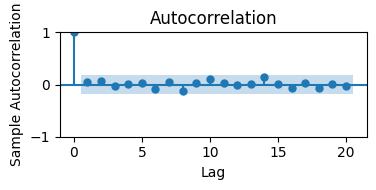

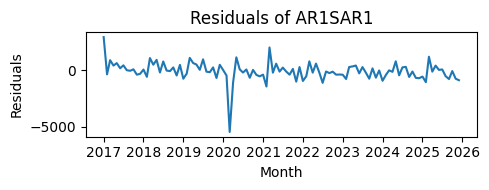

In [34]:
#| fig-cap: "Sample Autocorrelation function plot of ar1sar1 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(ar1sar1.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5, 2))
plt.title("Residuals of AR1SAR1")
plt.plot(crime_monthly['Month'], ar1sar1.resid, '-')
plt.xlabel('Month')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

# Final models

## For both variables:
My guess: 

Constant with differencing

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept       26.2274     32.269      0.813      0.416     -37.020      89.474
covid_during   -90.5117    181.937     -0.497      0.619    -447.101     266.078
covid_post     781.6007    301.744      2.590      0.010     190.194    1373.008
unemployment   -47.0808     11.757     -4.005      0.000     -70.123     -24.038
ar.L1           -0.3170      0.095     -3.336      0.001      -0.503      -0.131
ar.S.L12         0.7114      0.060     11.894      0.000       0.594       0.829
sigma2        1.451e+05   2.45e+04      5.922      0.000    9.71e+04    1.93e+05
Magnitude of AR roots: [1.02878662 1.02878662 1.02878662 1.02878662 1.02878662 1.02878662
 1.02878662 1.02878662 1.02878662 1.02878662 1.02878662 1.02878662
 3.15429751]
Magnitude of MA roots: []


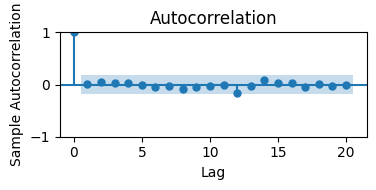

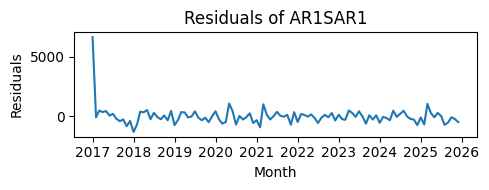

In [35]:
sarima_model = SARIMAX(no_of_incidents, order=(1, 1, 0), trend='c', exog = exog_vars, seasonal_order=(1, 0, 0, 12)).fit()

print(sarima_model.summary().tables[1])

ar_roots = sarima_model.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 

ma_roots = sarima_model.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) 

#| fig-cap: "Sample Autocorrelation function plot of ar1sar1 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(sarima_model.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5, 2))
plt.title("Residuals of AR1SAR1")
plt.plot(crime_monthly['Month'], sarima_model.resid, '-')
plt.xlabel('Month')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

Or, with linear trend:

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
drift           -0.4353      1.712     -0.254      0.799      -3.791       2.920
covid_during   -94.9859    774.932     -0.123      0.902   -1613.825    1423.853
covid_post    3829.5851    964.730      3.970      0.000    1938.748    5720.422
unemployment    -1.9644     20.198     -0.097      0.923     -41.552      37.623
ar.L1            0.9888      0.031     32.053      0.000       0.928       1.049
ar.S.L12         0.3598      0.073      4.898      0.000       0.216       0.504
sigma2        3.654e+05   7.68e+04      4.755      0.000    2.15e+05    5.16e+05
Magnitude of AR roots: [1.08892761 1.08892761 1.08892761 1.08892761 1.08892761 1.08892761
 1.08892761 1.08892761 1.08892761 1.08892761 1.08892761 1.01136208
 1.08892761]
Magnitude of MA roots: []


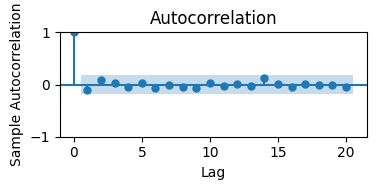

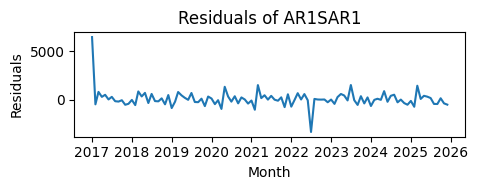

In [36]:
sarima_model = SARIMAX(no_of_incidents, order=(1, 0, 0), trend='t', exog = exog_vars, seasonal_order=(1, 0, 0, 12)).fit()

print(sarima_model.summary().tables[1])

ar_roots = sarima_model.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) 

ma_roots = sarima_model.maroots
print("Magnitude of MA roots:", np.abs(ma_roots)) 

#| fig-cap: "Sample Autocorrelation function plot of ar1sar1 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(sarima_model.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5, 2))
plt.title("Residuals of AR1SAR1")
plt.plot(crime_monthly['Month'], sarima_model.resid, '-')
plt.xlabel('Month')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()